In [1]:
import pandas as pd 
import numpy as np

#### Vou usar a leitura dos csvs sem comitar para rodar o comportamento das respostas. Depois teremos que trazer o csv tratado, corrigido e comitado.

In [29]:
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.csv', sep=';')
pd.read_csv ('funcionarios.csv', sep=';')
pd.read_csv ('reservas.csv', sep=';')
pd.read_csv ('tipos_quarto.csv', sep=';')
pd.read_csv ('unidades.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')

In [32]:
# 1. Cruzamento de Dados
# Anexando o valor da diária base na tabela de reservas
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')

In [33]:
# Anexando o nome da unidade para facilitar a visualização no gráfico
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')

In [34]:
# 2. Cálculo do Faturamento da Reserva (Receita Bruta)
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

In [35]:
# 3. Agrupamento: Faturamento Total por Unidade
faturamento_unidade = df_merged.groupby('nome_unidade')['faturamento_reserva'].sum().sort_values(ascending=False).reset_index()

In [36]:
# 4. Agrupamento: Valor Médio da Diária por Unidade
ticket_medio_unidade = df_merged.groupby('nome_unidade')['valor_diaria_base'].mean().sort_values(ascending=False).reset_index()


C:\Users\Robert\AppData\Local\Temp\ipykernel_13624\3426007479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_unidade, x='faturamento_reserva', y='nome_unidade', ax=axes[0], palette='viridis')
C:\Users\Robert\AppData\Local\Temp\ipykernel_13624\3426007479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_medio_unidade, x='valor_diaria_base', y='nome_unidade', ax=axes[1], palette='magma')


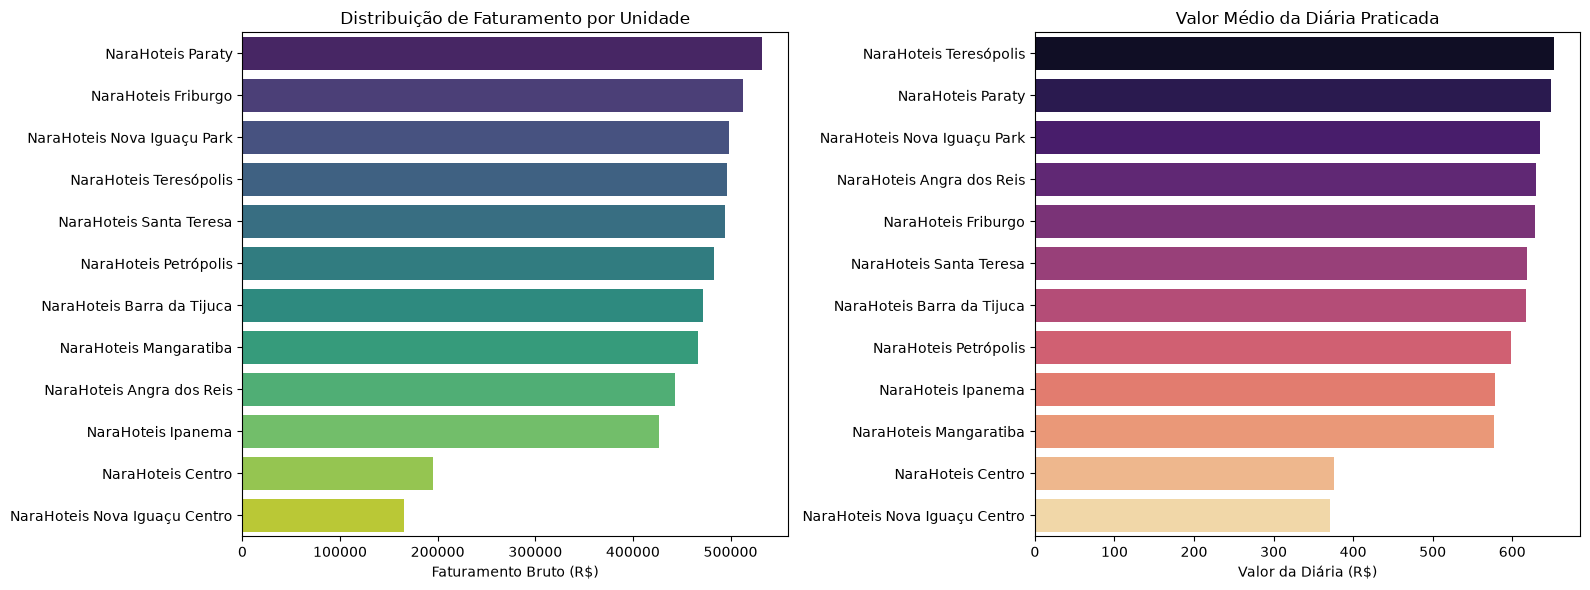

In [37]:
# Painel com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Faturamento Total
sns.barplot(data=faturamento_unidade, x='faturamento_reserva', y='nome_unidade', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição de Faturamento por Unidade')
axes[0].set_xlabel('Faturamento Bruto (R$)')
axes[0].set_ylabel('')

# Gráfico 2: Valor Médio da Diária
sns.barplot(data=ticket_medio_unidade, x='valor_diaria_base', y='nome_unidade', ax=axes[1], palette='magma')
axes[1].set_title('Valor Médio da Diária Praticada')
axes[1].set_xlabel('Valor da Diária (R$)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [38]:
# 1. Unindo os dois DataFrames (Faturamento e Diária Média) em uma única tabela
tabela_resumo = faturamento_unidade.merge(ticket_medio_unidade, on='nome_unidade')

# 2. Renomeando as colunas para um formato mais legível para negócios
tabela_resumo.columns = ['Unidade', 'Faturamento Total', 'Diária Média']

# 3. Criando uma função para formatar os valores para o padrão R$ (Moeda Brasileira)
def formatar_moeda(valor):
    # Formata com 2 casas decimais e separador de milhar americano, depois inverte para o padrão BR
    return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# 4. Aplicando a formatação nas colunas financeiras
tabela_resumo['Faturamento Total'] = tabela_resumo['Faturamento Total'].apply(formatar_moeda)
tabela_resumo['Diária Média'] = tabela_resumo['Diária Média'].apply(formatar_moeda)

# 5. Exibindo a tabela final formatada
display(tabela_resumo)

,Unidade,Faturamento Total,Diária Média
0,NaraHoteis Paraty,"R$ 531.760,00","R$ 648,74"
1,NaraHoteis Friburgo,"R$ 512.630,00","R$ 629,23"
2,NaraHoteis Nova Iguaçu Park,"R$ 498.930,00","R$ 635,23"
3,NaraHoteis Teresópolis,"R$ 496.570,00","R$ 652,54"
4,NaraHoteis Santa Teresa,"R$ 494.220,00","R$ 618,08"
5,NaraHoteis Petrópolis,"R$ 483.300,00","R$ 598,72"
6,NaraHoteis Barra da Tijuca,"R$ 472.200,00","R$ 617,55"
7,NaraHoteis Mangaratiba,"R$ 466.860,00","R$ 577,10"
8,NaraHoteis Angra dos Reis,"R$ 442.810,00","R$ 629,95"
9,NaraHoteis Ipanema,"R$ 427.080,00","R$ 578,55"


1. O Desempenho das Unidades "Centro" (Diferença de Perfil)

O que os dados mostram: As unidades NaraHoteis Centro (R$ 195 mil) e NaraHoteis Nova Iguaçu Centro (R$ 165 mil) apresentam faturamentos notavelmente menores que as demais (menos da metade da unidade em 9º lugar). A diária média dessas duas também é a menor da rede (R$ 376 e R$ 370).

Olhar de Negócios: Hotéis localizados em áreas de "Centro" costumam ter uma dinâmica voltada para o público corporativo e estadias mais curtas. O distanciamento tão grande dessas duas unidades em relação ao resto da rede indica que este modelo específico está gerando um volume de receita consideravelmente menor, sendo o principal ponto de atenção no faturamento global.

2. O Destaque dos Destinos Turísticos (Serra e Costa Verde)

O que os dados mostram: O topo do nosso ranking é dominado por destinos característicos de lazer e turismo: Paraty (1º), Friburgo (2º) e Nova Iguaçu Park (3º).

Olhar de Negócios: A operação atual está encontrando sua maior força nas unidades com perfil de lazer e descanso. Os hóspedes dessas regiões parecem estar confortáveis com diárias médias mais elevadas, o que está impulsionando o faturamento dessas unidades para a casa do meio milhão de reais.

3. A Relação Preço vs. Volume (O Caso de Teresópolis)

O que os dados mostram: Teresópolis possui a diária média mais alta de toda a rede (R$ 652,54), mas ocupa a 4ª posição no faturamento total.

Olhar de Negócios: Este é um excelente exemplo de que o maior preço nem sempre resulta na maior receita final. Esse dado nos convida a investigar, nos próximos passos, como está a taxa de ocupação dessa unidade. Pode ser que o valor mais alto da diária esteja resultando em um volume um pouco menor de reservas em comparação com Paraty e Friburgo.

4. Cenários Diferentes na Mesma Região (Nova Iguaçu)

O que os dados mostram: Temos duas unidades na mesma região (Baixada Fluminense) com resultados opostos. O Nova Iguaçu Park tem um ótimo desempenho (3º lugar, diária de R$ 635), enquanto o Nova Iguaçu Centro tem o menor faturamento da rede.

Olhar de Negócios: Isso nos mostra que a região, por si só, não é o fator limitante. A proposta de valor e a estrutura (uma voltada para "Park/Lazer" e outra para "Centro") provavelmente são bem diferentes, o que justifica a diferença de quase 70% no valor da diária entre elas.

5. O Posicionamento de Ipanema

O que os dados mostram: Ipanema está na 9ª posição em faturamento e com uma diária média (R$ 578) abaixo de unidades na Serra e Costa Verde.

Olhar de Negócios: Considerando que Ipanema é uma localização tradicionalmente muito valorizada no Rio de Janeiro, ver a unidade na metade inferior do ranking levanta uma dúvida natural. É uma unidade estratégica que merecerá um olhar cuidadoso quando formos analisar as avaliações dos clientes e a infraestrutura, para entender o que pode estar segurando seu potencial.

### Respposta 2